# **Import labraries**
---

In [79]:
#Import the following libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Import a statistical model specifically for ordinal dependent variables.
from statsmodels.miscmodels.ordinal_model import OrderedModel


In [80]:
#Create forder on notebooks
!mkdir -p project/notebooks
!mkdir -p project/charts

In [81]:
#To display data in a nice tabular format (for convert to markdown)
!pip install tabulate

# **Load data**
---

In [82]:
df = pd.read_csv('https://raw.githubusercontent.com/phuongdn277-cmyk/FINAL-PROJECT-FACTORS-AFFECTING-MENTAL-HEALTH-OUTCOMES/refs/heads/main/data/Global_Mental_Health_Dataset_2025.csv')
df.sample(5)

,Patient_ID,Age,Gender,Country,Depression_Score,Anxiety_Score,Stress_Level,Sleep_Hours,Physical_Activity,Chronic_Illness,Mental_Health_History,Treatment,Days_of_Treatment,Outcome,Work_Status
999,MH1000,22,Male,Germany,15,6,Medium,7.3,High,No,Yes,NaN,145,Good,Employed
1601,MH1602,80,Female,Canada,7,10,High,10.2,Moderate,No,No,Therapy,240,Good,Unemployed
1220,MH1221,69,Male,Brazil,3,14,High,6.3,Moderate,No,No,NaN,220,Fair,Student
2345,MH2346,39,Male,United States,17,14,High,5.6,Low,Yes,No,NaN,13,Fair,Employed
1457,MH1458,50,Female,United Kingdom,26,0,High,9.4,Low,No,No,Therapy,75,Good,Employed


In [83]:
print(df.sample(5).to_markdown())

|      | Patient_ID   |   Age | Gender   | Country   |   Depression_Score |   Anxiety_Score | Stress_Level   |   Sleep_Hours | Physical_Activity   | Chronic_Illness   | Mental_Health_History   | Treatment   |   Days_of_Treatment | Outcome   | Work_Status   |
|-----:|:-------------|------:|:---------|:----------|-------------------:|----------------:|:---------------|--------------:|:--------------------|:------------------|:------------------------|:------------|--------------------:|:----------|:--------------|
|  943 | MH0944       |    66 | Male     | Brazil    |                 22 |               9 | Medium         |           7.2 | Low                 | Yes               | No                      | Therapy     |                  39 | Good      | Employed      |
| 1543 | MH1544       |    27 | Male     | Germany   |                  5 |              12 | High           |          10.8 | Moderate            | No                | No                      | nan         |               

# **Data Cleaning**
---

## Data overview
---

In [84]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             2500 non-null   object 
 1   Age                    2500 non-null   int64  
 2   Gender                 2500 non-null   object 
 3   Country                2500 non-null   object 
 4   Depression_Score       2500 non-null   int64  
 5   Anxiety_Score          2500 non-null   int64  
 6   Stress_Level           2500 non-null   object 
 7   Sleep_Hours            2500 non-null   float64
 8   Physical_Activity      2023 non-null   object 
 9   Chronic_Illness        2500 non-null   object 
 10  Mental_Health_History  2500 non-null   object 
 11  Treatment              1892 non-null   object 
 12  Days_of_Treatment      2500 non-null   int64  
 13  Outcome                2500 non-null   object 
 14  Work_Status            2500 non-null   object 
dtypes: f

,Age,Depression_Score,Anxiety_Score,Sleep_Hours,Days_of_Treatment
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,49.580800,13.518400,10.502800,7.461600,179.720400
std,18.213933,8.082561,6.329267,2.591345,107.400884
min,18.000000,0.000000,0.000000,3.000000,0.000000
25%,34.000000,6.000000,5.000000,5.300000,86.000000
50%,50.000000,14.000000,11.000000,7.500000,180.000000
75%,66.000000,21.000000,16.000000,9.700000,271.250000
max,80.000000,27.000000,21.000000,12.000000,365.000000


**Range and Logical Check:**
**Base on describe, min/ max of each numeric columns is suitable logical and values ​​within the range**
*   Age: 18-80
*   Depression_Score: 0-27 (PHQ-9 scale)
*   Anxiety_Score: 0-21 (GAD-7 scale)
*   Sleep_Hours: 1 =< &=< 24
*   Days_of_Treatment: 0-366 (Number of days in a year)












In [85]:

print(df.describe().to_markdown())

|       |       Age |   Depression_Score |   Anxiety_Score |   Sleep_Hours |   Days_of_Treatment |
|:------|----------:|-------------------:|----------------:|--------------:|--------------------:|
| count | 2500      |         2500       |      2500       |    2500       |            2500     |
| mean  |   49.5808 |           13.5184  |        10.5028  |       7.4616  |             179.72  |
| std   |   18.2139 |            8.08256 |         6.32927 |       2.59134 |             107.401 |
| min   |   18      |            0       |         0       |       3       |               0     |
| 25%   |   34      |            6       |         5       |       5.3     |              86     |
| 50%   |   50      |           14       |        11       |       7.5     |             180     |
| 75%   |   66      |           21       |        16       |       9.7     |             271.25  |
| max   |   80      |           27       |        21       |      12       |             365     |


## Check each record represents an anonymous patient
---

In [86]:

df['Patient_ID'].is_unique

True

## Check consistency, Correct Data Types and Handle 2 columns with missing data: Physical_Activity, Treatment
---

In [87]:
categorical_cols = ['Physical_Activity','Treatment','Gender','Stress_Level','Chronic_Illness','Mental_Health_History','Outcome','Work_Status']
for col in categorical_cols :
  print(col,":",df[col].unique())

Physical_Activity : ['Moderate' 'Low' nan 'High']
Treatment : ['Therapy' nan 'Medication' 'Both']
Gender : ['Male' 'Female']
Stress_Level : ['High' 'Severe' 'Low' 'Medium']
Chronic_Illness : ['No' 'Yes']
Mental_Health_History : ['No' 'Yes']
Outcome : ['Excellent' 'Fair' 'Good' 'Poor']
Work_Status : ['Unemployed' 'Employed' 'Student' 'Retired']


In [88]:
# Handle missing value
df['Physical_Activity'].fillna(df['Physical_Activity'].mode()[0],inplace=True)
df['Treatment'].fillna('Unknown', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             2500 non-null   object 
 1   Age                    2500 non-null   int64  
 2   Gender                 2500 non-null   object 
 3   Country                2500 non-null   object 
 4   Depression_Score       2500 non-null   int64  
 5   Anxiety_Score          2500 non-null   int64  
 6   Stress_Level           2500 non-null   object 
 7   Sleep_Hours            2500 non-null   float64
 8   Physical_Activity      2500 non-null   object 
 9   Chronic_Illness        2500 non-null   object 
 10  Mental_Health_History  2500 non-null   object 
 11  Treatment              2500 non-null   object 
 12  Days_of_Treatment      2500 non-null   int64  
 13  Outcome                2500 non-null   object 
 14  Work_Status            2500 non-null   object 
dtypes: f

/tmp/ipython-input-3907982437.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Physical_Activity'].fillna(df['Physical_Activity'].mode()[0],inplace=True)
/tmp/ipython-input-3907982437.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [89]:
# Correct data types
df[categorical_cols] = df[categorical_cols].astype('category')
for col in categorical_cols :
  print(col,":",df[col].unique())

Physical_Activity : ['Moderate', 'Low', 'High']
Categories (3, object): ['High', 'Low', 'Moderate']
Treatment : ['Therapy', 'Unknown', 'Medication', 'Both']
Categories (4, object): ['Both', 'Medication', 'Therapy', 'Unknown']
Gender : ['Male', 'Female']
Categories (2, object): ['Female', 'Male']
Stress_Level : ['High', 'Severe', 'Low', 'Medium']
Categories (4, object): ['High', 'Low', 'Medium', 'Severe']
Chronic_Illness : ['No', 'Yes']
Categories (2, object): ['No', 'Yes']
Mental_Health_History : ['No', 'Yes']
Categories (2, object): ['No', 'Yes']
Outcome : ['Excellent', 'Fair', 'Good', 'Poor']
Categories (4, object): ['Excellent', 'Fair', 'Good', 'Poor']
Work_Status : ['Unemployed', 'Employed', 'Student', 'Retired']
Categories (4, object): ['Employed', 'Retired', 'Student', 'Unemployed']


In [90]:
df.head(5)

,Patient_ID,Age,Gender,Country,Depression_Score,Anxiety_Score,Stress_Level,Sleep_Hours,Physical_Activity,Chronic_Illness,Mental_Health_History,Treatment,Days_of_Treatment,Outcome,Work_Status
0,MH0001,56,Male,Germany,4,10,High,8.2,Moderate,No,No,Therapy,171,Excellent,Unemployed
1,MH0002,69,Male,South Africa,22,4,Severe,6.2,Low,No,Yes,Unknown,69,Fair,Employed
2,MH0003,46,Male,South Africa,4,2,Low,10.4,Moderate,Yes,Yes,Medication,70,Good,Employed
3,MH0004,32,Female,Australia,19,16,Low,10.0,Moderate,No,Yes,Both,254,Excellent,Employed
4,MH0005,60,Female,United States,14,1,Severe,7.9,Low,Yes,No,Therapy,130,Fair,Employed


# **Exploratory Data Analysis**

The following groups of variables are analyzed to understand their influence on the **Outcome variable**:

- **Demographic**: Age, Gender, Country, Work_Status  
- **Clinical**: Depression_Score, Anxiety_Score, Chronic_Illness, Stress_Level, Mental_Health_History  
- **Lifestyle**: Sleep_Hours, Physical_Activity  
- **Treatment**: Treatment, Days_of_Treatment  

## **Overview of outcome**

---

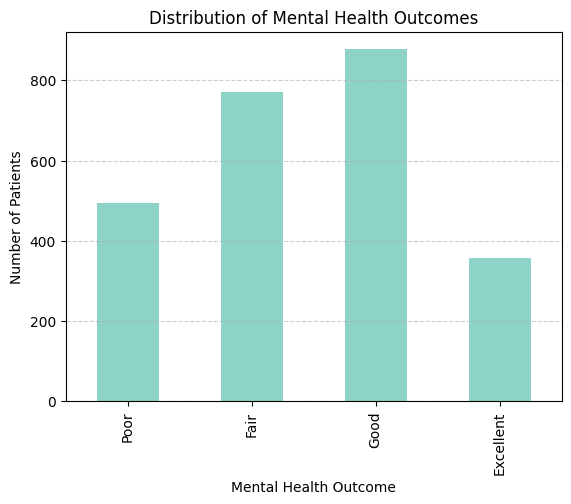

In [91]:

#sort Outcome & count
outcome_sort = ['Poor','Fair','Good','Excellent']
outcome_counts = (df['Outcome'].value_counts().reindex(outcome_sort))

#bar chart
plt.figure()
outcome_counts.plot(kind='bar',colormap='Set3')
plt.xlabel('Mental Health Outcome')
plt.ylabel('Number of Patients')
plt.title('Distribution of Mental Health Outcomes')
plt.savefig('project/charts/overview_outcome.png',dpi=300)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Conclusion:**  Most patient were classified as Good or Fair, with the lowest number in the Excellent group. The outcome distribution shows that the data is skewed towards the fair-good group, while the two extremes (poor and excellent) are less common.

## **Demographic**: Age, Gender, Country, Work_Status

---



### Age
---

/tmp/ipython-input-1375329637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome',y='Age', data=df,


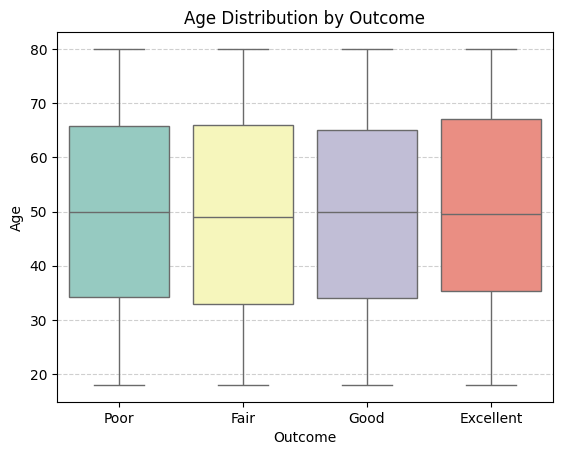

In [92]:
# Age
sns.boxplot(x='Outcome',y='Age', data=df,
    order=outcome_sort,
    palette='Set3')
plt.title('Age Distribution by Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('project/charts/age_distribution.png',dpi=300)

plt.show()

**Conclusion:**
+ The boxplot illustrates the distribution of **Age** across different mental health **Outcome** categories.
+ The median **Age** of the groups & Interquaritile Range (IQR) are almost identical, indicating no clear age trend associated with mental health **Outcome**
+ Ages ranged from approximately 18 to 80 across all outcomes, indicating that poor or excellent outcomes can occur at any age.

**In summary**: This suggests that age isn't a strong determinant of mental health outcomes in this dataset.



### Gender
---

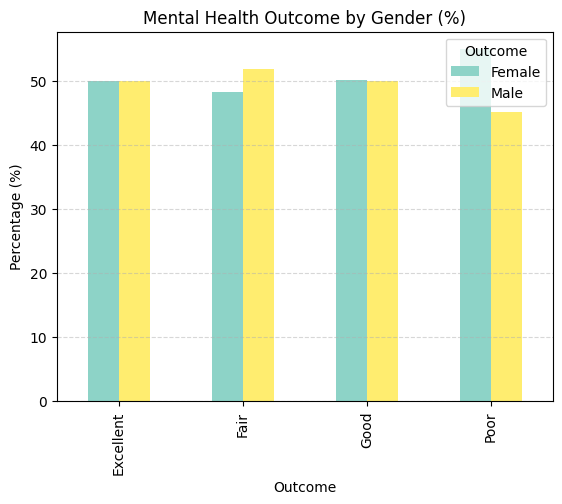

In [93]:

# Gender (%)
gender_pct = pd.crosstab(df['Outcome'],df['Gender'],normalize='index') * 100

gender_pct.plot(
    kind='bar',
    colormap='Set3',
)
plt.title('Mental Health Outcome by Gender (%)')
plt.ylabel('Percentage (%)')
plt.legend(title='Outcome',loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('project/charts/outcome_by_gender_percantage.png',dpi=300)
plt.show()


**Conclusion:**

**- Gender:** The Good group accounted for the highest proportion in both genders. The distribution of outcomes between male and female is quite similar. The Poor group in Female is higher than Male, Females have a slightly higher risk of a less favorable outcome compared to males, but the difference is not significant.

Overall, gender does not appear to be a strong differentiating factor in mental health outcomes, as the percentage distribution across outcome categories is largely comparable.



### Country & Work_status
---

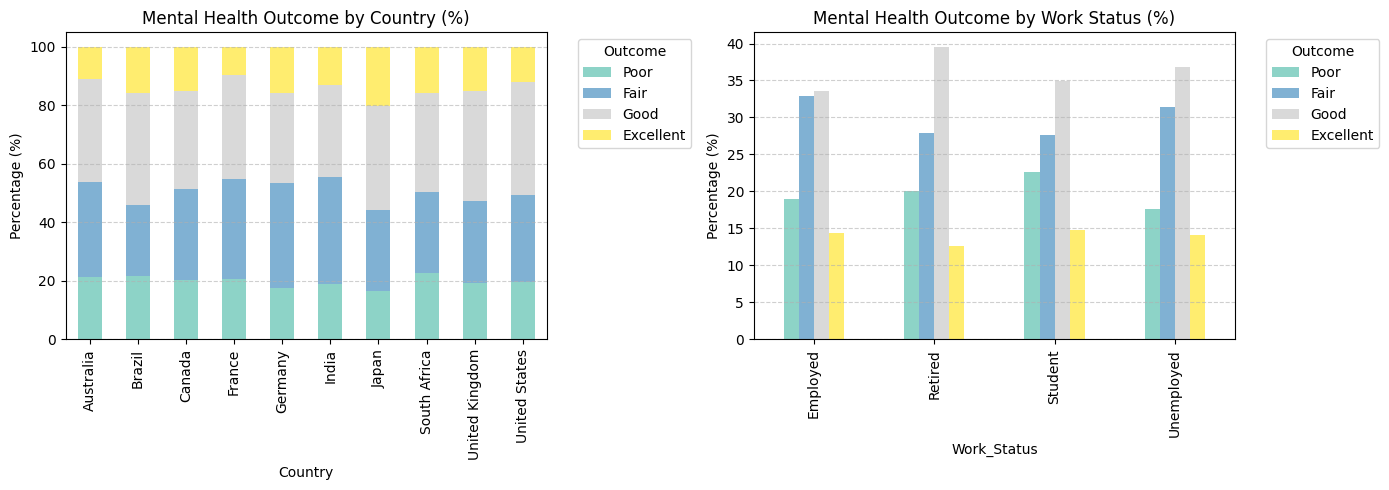

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Country
country_pct = pd.crosstab(
    df['Country'],
    df['Outcome'],
    normalize='index'
) * 100
country_pct = country_pct[outcome_sort]

country_pct.plot(kind='bar',stacked=True,colormap='Set3',ax=axes[0])
axes[0].set_title('Mental Health Outcome by Country (%)')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Percentage (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[0].legend(title='Outcome',bbox_to_anchor=(1.05,1),loc='upper left')

# Work_Status (%)
work_pct = pd.crosstab(
    df['Work_Status'],
    df['Outcome'],
    normalize='index'
) * 100
work_pct = work_pct[outcome_sort]

work_pct.plot(
    kind='bar',
    colormap='Set3',
    ax=axes[1]
)
axes[1].set_title('Mental Health Outcome by Work Status (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Outcome',loc='best')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].legend(title='Outcome',bbox_to_anchor=(1.05,1),loc='upper left')

plt.tight_layout()
plt.savefig('project/charts/outcome_by_workstatus_country_percantage.png',dpi=300)
plt.show()

**Conclusion:**

-**Country:** strongly influences the distribution of mental health outcomes.
+ **South Africa** and **Brazil** exhibit a higher proportion of **Poor** mental health outcomes compared to other countries, while their share of **Excellent** outcomes is relatively lower.
+ In contrast, **Japan** stands out with the lowest percentage of **Poor** outcomes and the highest percentage of **Excellent** outcomes.
+ Across most countries, **Good** outcomes account for the largest proportion, while **Fair** outcomes remain consistently high.

These patterns suggest that country-level context plays an important role in shaping mental health outcomes.

**- Work Status:** Mental health outcomes vary more clearly across different work status groups.
+ **Retired** has a ratio **Good** Outcome highest (about 40%).
+ **Student** the highest percentage of "Poor" outcome (about 23%). The percentage of "Good" outcome was lower compared to other groups (Retired & Unemployed).
+ **Employed** the lowest Good outcome ratio and the highest Fair outcome ratio compared to other groups.

These  suggest that work status is more strongly associated with mental health outcomes, reflecting the influence of social and economic context on mental well-being. Among them, **Students** and the **Employed** are the two groups at highest risk.


## **Clinical**: Depression_Score, Anxiety_Score, Chronic_Illness, Stress_Level, Mental_Health_History

---



### Depression_Score & Anxiety_Score
---

/tmp/ipython-input-3477003478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='Depression_Score', ax=axes[0],
/tmp/ipython-input-3477003478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='Anxiety_Score', ax=axes[1],


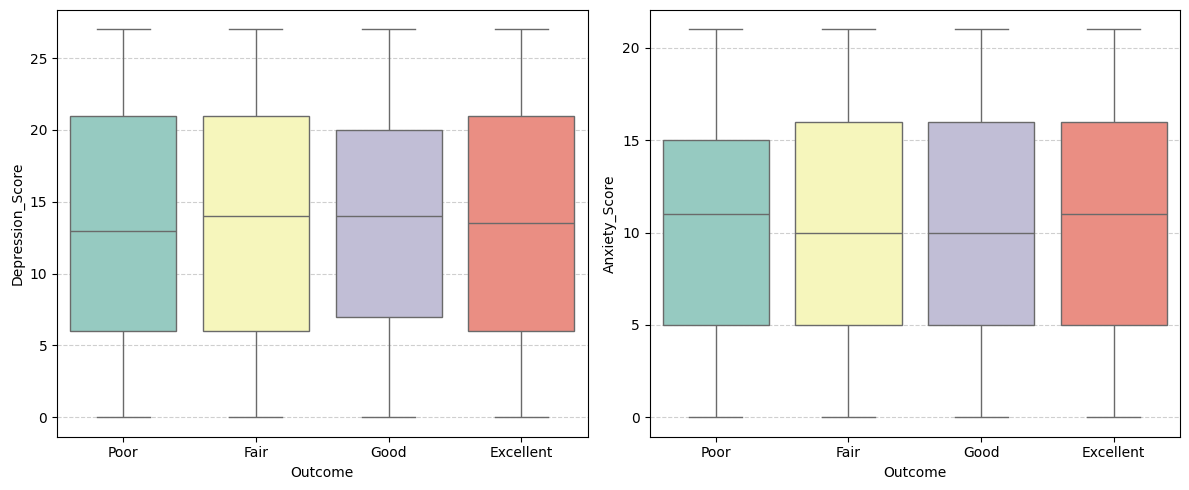

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='Outcome', y='Depression_Score', ax=axes[0],
            order=outcome_sort,
            palette='Set3')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

sns.boxplot(data=df, x='Outcome', y='Anxiety_Score', ax=axes[1],
            order=outcome_sort,
            palette='Set3')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('project/charts/outcome_by_depression_anxiety',dpi=300)
plt.show()

**Conclusion**: The distributions of Depression and Anxiety scores largely overlap across outcome groups, with similar medians and wide variability. This suggests that while these scores may be associated with mental health outcomes, they do not strongly differentiate between outcome categories on their own.

+ Median of the both groups didn't decrease/ increase significantly according to **Outcome**
+ IQR is wide across all **Outcome**

**Outcome** can be a composite variable, influenced by many factors other than Depression Score and Anxiety Score.


### Chronic_Illness & Mental_Health_History (Binary Yes/ No)
---

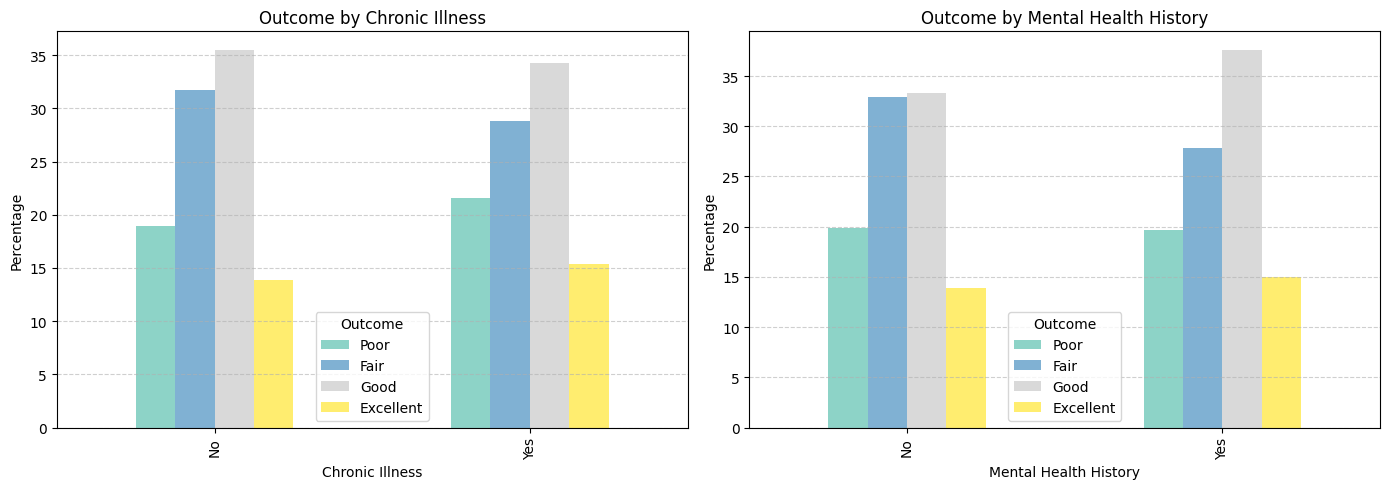

In [96]:
fid,axes = plt.subplots(1,2,figsize=(14,5))

Chronic_Illness_pct = pd.crosstab(df['Chronic_Illness'],df['Outcome'],normalize='index')*100
Chronic_Illness_pct = Chronic_Illness_pct[outcome_sort]
Chronic_Illness_pct.plot(kind='bar',colormap='Set3',ax=axes[0])
axes[0].set_title('Outcome by Chronic Illness')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Chronic Illness')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

Mental_Health_History_pct = pd.crosstab(df['Mental_Health_History'],df['Outcome'],normalize = 'index')*100
Mental_Health_History_pct = Mental_Health_History_pct[outcome_sort]
Mental_Health_History_pct.plot(kind='bar',colormap='Set3',ax = axes[1])
axes[1].set_title('Outcome by Mental Health History')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Mental Health History')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('project/charts/outcome_by_chronicilll_mhh',dpi=300)
plt.show()

**Conclusion:**
+ **Chronic Illness:** The **No** group had a lower rate of **Poor** outcomes and a higher rate of **Good** outcomes compared to the **Yes** group. The **Outcome** distribution in the **No** group was more positive. This suggests that the presence of **Chronic Illness** is associated with poorer **Mental Health Outcomes**.

+ **Mental Health History:** The **Yes** group had a lower rate of **Poor** & **Fair** outcomes and a higher rate of **Good** & **Excellent** outcomes compared to the **No** group. This reflects the fact that the group with a history of mental health issues and prior treatment experience had better outcomes.


### Stress_Level
---

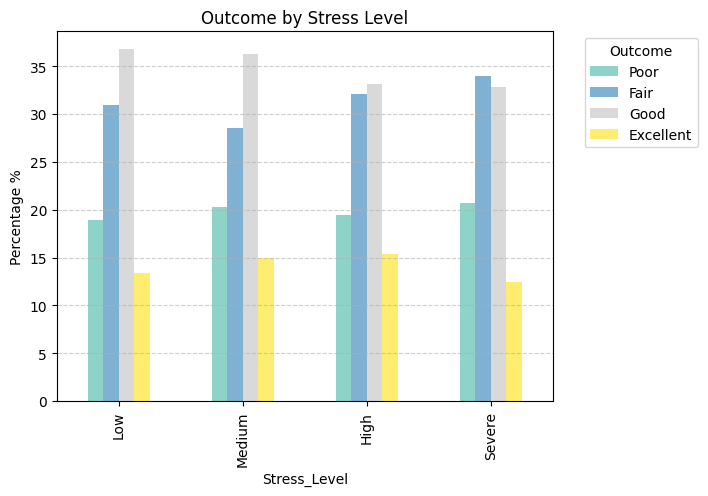

In [97]:
stresslevel_sort = ['Low', 'Medium','High', 'Severe']

ct = pd.crosstab(df['Stress_Level'],df['Outcome'],normalize='index')*100
ct = ct.reindex(stresslevel_sort)
ct = ct [outcome_sort]

ct.plot(kind='bar', colormap='Set3')
plt.title('Outcome by Stress Level')
plt.ylabel('Percentage %')
plt.legend(title='Outcome',bbox_to_anchor=(1.05,1),loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('project/charts/outcome_by_stresslevel',dpi=300)
plt.show()

**Conclusion**: Outcome distribution changes gradually with each level of stress. The Fair and Poor ratings increase progressively and are highest in the **Severe** group. The highest percentage of Good cases was in the **Low** and **Medium** groups, decreasing significantly in the **Severe** group. It indicating a negative relationship between stress severity and mental well-being.



## **Lifestyle**: Sleep_Hours, Physical_Activity

---



### Sleep_Hours
---

/tmp/ipython-input-2133763610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Sleep_Hours', data=df, order=outcome_sort,palette='Set3')


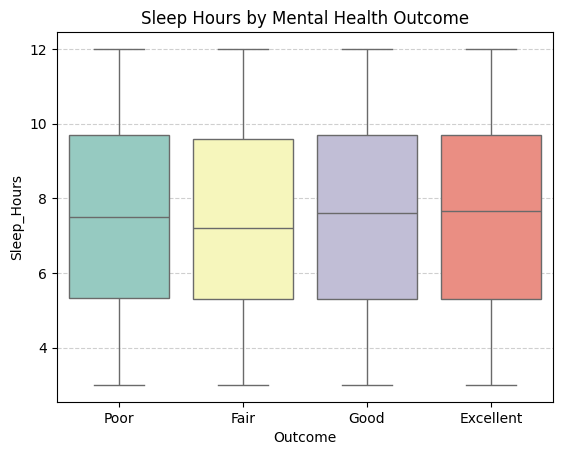

In [98]:
sns.boxplot(x='Outcome', y='Sleep_Hours', data=df, order=outcome_sort,palette='Set3')
plt.title('Sleep Hours by Mental Health Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('project/charts/outcome_by_sleephours',dpi=300)
plt.show()

**Conclusion:** Median sleep hours were almost the same across the groups (7-8 hours). The boxplots overlapped strongly. This suggests that sleep duration alone is not a strong differentiating factor of mental health outcomes.

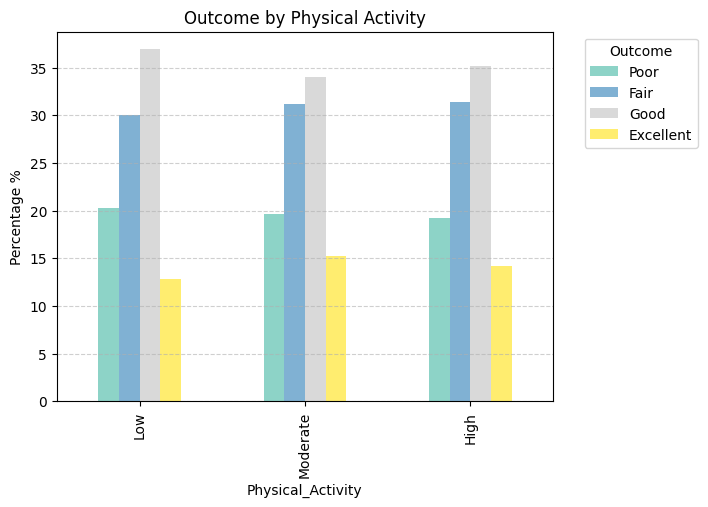

In [99]:
physical_activity_sort = ['Low', 'Moderate','High']

pa = pd.crosstab(df['Physical_Activity'],df['Outcome'],normalize='index')*100
pa = pa.reindex(physical_activity_sort)
pa = pa [outcome_sort]

pa.plot(kind='bar', colormap='Set3')
plt.title('Outcome by Physical Activity')
plt.ylabel('Percentage %')
plt.legend(title='Outcome',bbox_to_anchor=(1.05,1),loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('project/charts/outcome_by_physical_activity',dpi=300)
plt.show()

**Conclusion:** As the level of physical activity increases (Low → Moderate → High):
The percentage of Poor tends to decrease slightly.
The percentage of Excellent tends to increase.
The changes between the groups are relatively slight.
The columns do not differ too strongly.

Higher levels of physical activity are associated with a modest improvement in mental health outcomes. However, the overall distribution remains dominated by Good outcomes across all activity levels, indicating that physical activity alone doesn't fully explain mental health status.

## **Treatment**: Treatment, Days_of_Treatment

---



### Treatment
---

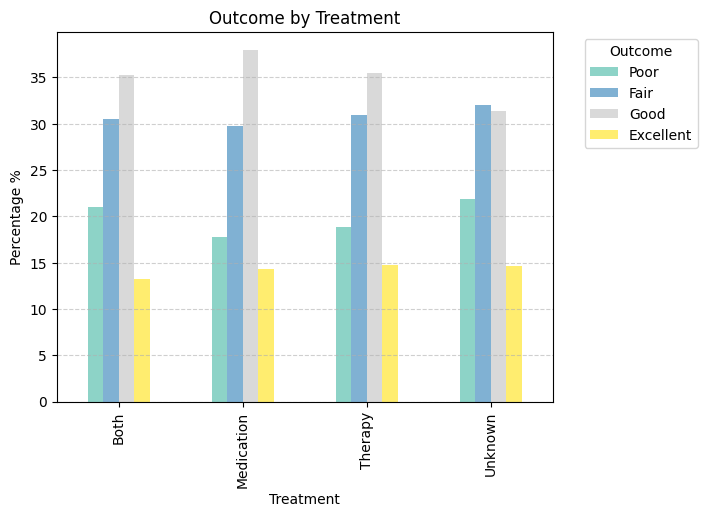

In [100]:
treatment_pct = pd.crosstab(df['Treatment'],df['Outcome'],normalize='index')*100
treatment_pct = treatment_pct[outcome_sort]

treatment_pct.plot(kind='bar',colormap='Set3')
plt.title('Outcome by Treatment')
plt.ylabel('Percentage %')
plt.legend(title='Outcome',bbox_to_anchor=(1.05,1),loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('project/charts/outcome_by_treatment',dpi=300)
plt.show()

**Conclusion:** The treatment groups had different outcomes, but they weren't too far apart.
Outcomes were generally fairly consistent across the different treatment methods.

While individuals receiving medication or therapy tend to show slightly more favorable outcome distributions, the overall differences are limited, suggesting that treatment type alone may not fully explain outcome variation.

### Days_of_Treatment
---

/tmp/ipython-input-1408576409.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Days_of_Treatment', data=df, order=outcome_sort,palette='Set3')


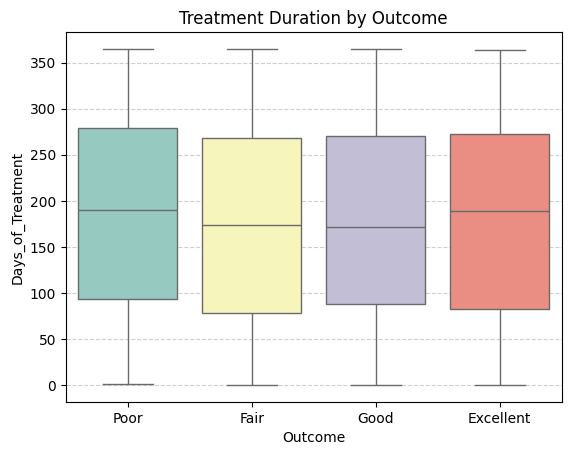

In [101]:
sns.boxplot(x='Outcome', y='Days_of_Treatment', data=df, order=outcome_sort,palette='Set3')
plt.title('Treatment Duration by Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('project/charts/treatment_duration_by_outcome',dpi=300)
plt.show()

**Conclusion:**
While treatment type shows differences in outcome distribution, treatment duration alone does not strongly differentiate mental health outcomes, suggesting that treatment effectiveness depends on multiple interacting factors rather than duration alone.

## **Correlation**

---



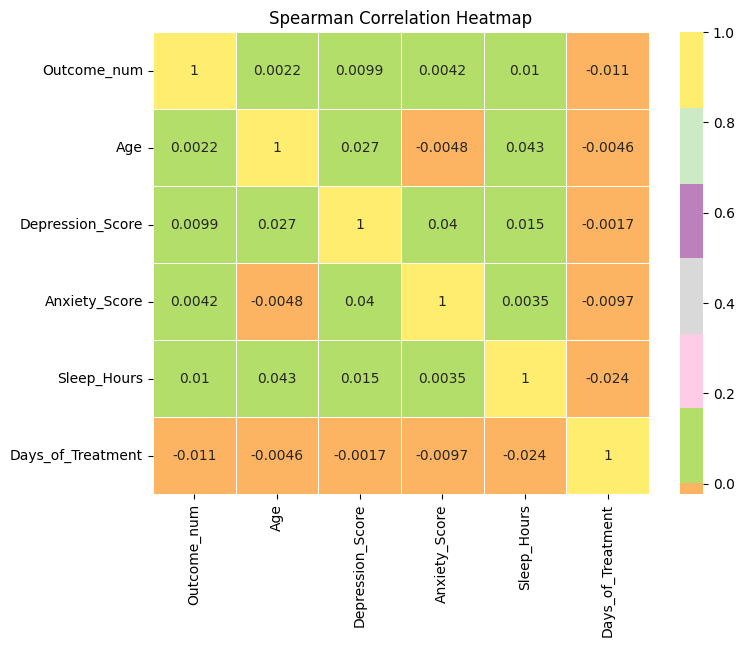

In [102]:
# 1. Encode Outcome thành số ordinal (Poor < Fair < Good < Excellent)
outcome_map = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
df['Outcome_num'] = df['Outcome'].map(outcome_map)

# 2. Chọn các biến numeric
numeric_cols = ['Outcome_num','Age', 'Depression_Score', 'Anxiety_Score', 'Sleep_Hours', 'Days_of_Treatment']
df_corr = df[numeric_cols]

# 3. Tính Spearman correlation
corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='Set3',center=0,linewidths=0.5)

plt.title('Spearman Correlation Heatmap')
plt.savefig('project/charts/spearman_correlation_heatmap.png',dpi=300)
plt.show()


**Conclusion**: The Spearman coefficients between Outcome_num and the other variables are all close to 0, indicating no significant monotonic relationship exists between Outcome and these variables.
This is consistent with overlapping Boxplots and Bar charts that did not show much difference previously.

## **Ordinal Logistic Regression**

---



In [103]:
# Ordinal-encoded Outcome
df['Outcome_ord'] = pd.Categorical(
    df['Outcome'],
    categories=outcome_sort,
    ordered=True
).codes
df['Outcome_ord']

# Encode Stress_Level ( Low <  Medium < High < Severe)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Severe': 3}
df['Stress_num'] = df['Stress_Level'].map(stress_map)
df['Stress_num'] = df['Stress_num'].astype(int)

# Encode Physical_Activity ( Low <  Moderate < High)
activity_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Activity_num'] = df['Physical_Activity'].map(activity_map)
df['Activity_num'] = df['Activity_num'].astype(int)

# Encode Chronic_Illness (Yes/No)
df['Chronic_Illness_bin'] = df['Chronic_Illness'].map({
    'No': 0,
    'Yes': 1
})
df['Chronic_Illness_bin'] = df['Chronic_Illness_bin'].astype(int)

# Encode Mental_Health_History (Yes/No)
df['Mental_Health_History_bin'] = df['Mental_Health_History'].map({
    'No': 0,
    'Yes': 1
})
df['Mental_Health_History_bin'] = df['Mental_Health_History_bin'].astype(int)


In [104]:
# Convert categorical nominal variables into multiple binary columns (0/1)
X = pd.get_dummies(df[['Stress_num','Activity_num',
    'Chronic_Illness_bin','Mental_Health_History_bin',
    'Work_Status','Country','Treatment',
    'Age', 'Depression_Score', 'Anxiety_Score', 'Sleep_Hours', 'Days_of_Treatment',]]
                   ,drop_first=True)

# Convert column with boolean value to integer
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)


y = df['Outcome_ord']
model_ord = OrderedModel(y,X,distr='logit')
result_ord = model_ord.fit(method='bfgs')
print(result_ord.summary())

Optimization terminated successfully.
         Current function value: 1.324185
         Iterations: 65
         Function evaluations: 70
         Gradient evaluations: 70
                             OrderedModel Results                             
Dep. Variable:            Outcome_ord   Log-Likelihood:                -3310.5
Model:                   OrderedModel   AIC:                             6675.
Method:            Maximum Likelihood   BIC:                             6832.
Date:                Wed, 31 Dec 2025                                         
Time:                        10:16:33                                         
No. Observations:                2500                                         
Df Residuals:                    2473                                         
Df Model:                          24                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

In [105]:
# Get the coefficient table.
coef_table = result_ord.summary().tables[1]

# Convert to DataFrame
coef_df = pd.DataFrame(
    coef_table.data[1:],   # bỏ header
    columns=coef_table.data[0]
)

# print Markdown
print(coef_df.to_markdown(index=False))

|                           |    coef |   std err |      z |   P>|z| |   [0.025 |   0.975] |
|:--------------------------|--------:|----------:|-------:|--------:|---------:|---------:|
| Stress_num                | -0.0368 |     0.037 | -1.004 |   0.315 |   -0.109 |    0.035 |
| Activity_num              |  0.0087 |     0.054 |  0.159 |   0.874 |   -0.098 |    0.115 |
| Chronic_Illness_bin       | -0.0052 |     0.08  | -0.065 |   0.948 |   -0.161 |    0.151 |
| Mental_Health_History_bin |  0.1349 |     0.074 |  1.82  |   0.069 |   -0.01  |    0.28  |
| Age                       |  0.0001 |     0.002 |  0.066 |   0.947 |   -0.004 |    0.004 |
| Depression_Score          |  0.002  |     0.005 |  0.451 |   0.652 |   -0.007 |    0.011 |
| Anxiety_Score             |  0.001  |     0.006 |  0.167 |   0.867 |   -0.01  |    0.012 |
| Sleep_Hours               |  0.0053 |     0.014 |  0.374 |   0.708 |   -0.022 |    0.033 |
| Days_of_Treatment         | -0.0002 |     0     | -0.63  |   0.529 |

**Conclusion:** An ordinal logistic regression model was applied to examine factors influencing mental health outcomes.

+ **Stress_level**: has a coef of -0.0368 and a p-value of 0.315 (p-value > 0.05) => Stress level doesn't have a significant effect on mental health outcome.
+ **Country**:
  + Japan: has a p-value of 0.007 (p-value < 0.05) => Japan have a statistically significant effect on mental health outcome. Coef (0.4468) => Odds Ratio about 1.56. People in Japan are approximately 56% more likely to achieve better mental health outcomes compared to the baseline.
  + Orther Country has a p-value > 0.05 => doesn't have a significant effect on mental health outcome

+ Other demographic, clinical, lifestyle, and treatment-related variables did not exhibit statistically significant effects within this multivariate framework



# **Final Colusion:**
**Demographic Factors**

Overall, among demographic variables, work status and country show noticeable differences in mental health outcomes at the descriptive level. However, after controlling for other factors, country context—particularly Japan—emerges as the most influential demographic factor. Age and gender haven't statistically significant effect on mental health outcomes.

**Clinical Factors**

In general, higher stress levels display a negative directional trend in descriptive analyses. Depression score, anxiety score, chronic illness, and mental health history are related to mental health outcomes; however, none of these factors independently determines the outcome. Their effects appear modest and context-dependent, rather than decisive predictors.

**Lifestyle Factors**

Sleep duration and physical activity do not strongly differentiate mental health outcomes in this dataset. While small variations are observable, these lifestyle factors do not exhibit strong or consistent associations with outcome levels.

**Treatment Factors**

Mental health outcomes appear to depend on multiple interacting factors rather than treatment duration or treatment type alone. No clear evidence suggests that specific treatment methods or longer treatment duration independently lead to better outcomes.

**Correlation Analysis**

Correlation analysis shows that numeric variables (Age, Depression Score, Anxiety Score, Sleep Hours, and Days of Treatment) have very low correlation coefficients (|ρ| ≤ 0.01) with mental health outcomes, indicating no strong monotonic or linear relationships. This finding aligns with earlier exploratory and regression analyses.

**Ordinal Logistic Regression**

Ordinal logistic regression confirms that mental health outcomes are not driven by any single numeric or clinical variable. While stress and health indicators show modest patterns in descriptive analysis, only country-level context—specifically Japan—remains a statistically significant predictor after adjustment. This suggests that broader contextual and systemic factors play a more substantial role in shaping mental health outcomes than individual-level indicators alone.

**Limitations**

This study has several limitations. Most notably, the dataset lacks key socioeconomic and environmental variables, such as income, healthcare access, and social support, which restricts the ability to fully explain variations in mental health outcomes across individuals and countries.

**Future Work**

Incorporating additional socioeconomic and contextual variables, such as income, healthcare access, and social support, would provide a more comprehensive understanding of mental health determinants.

